In [5]:
import pandas as pd 
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,mean_absolute_error,classification_report,confusion_matrix,roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import shap

In [6]:
df = pd.read_csv("../data/telco_churn.csv")

df["TotalCharges"] = df["TotalCharges"].replace(" ", 0)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

In [7]:
X = df.drop(columns=["Churn", "customerID"])
y = df["Churn"].map({"No": 0, "Yes": 1})

In [8]:
print(X.shape)
print(y.shape)

(7043, 19)
(7043,)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [10]:
print(X_train.shape)
print(X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(5634, 19)
(1409, 19)
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [12]:
df.select_dtypes(include=["object"])

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
0,7590-VHVEG,Female,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,No
1,5575-GNVDE,Male,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,No
2,3668-QPYBK,Male,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,Yes
3,7795-CFOCW,Male,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),No
4,9237-HQITU,Female,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,Yes,Yes,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,No
7039,2234-XADUH,Female,Yes,Yes,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),No
7040,4801-JZAZL,Female,Yes,Yes,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
7041,8361-LTMKD,Male,Yes,No,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,Yes


In [13]:
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=['number']).columns

In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("numerical", StandardScaler(), numerical_cols)
    ]
)

In [15]:
preprocessor

,transformers,"[('categorical', ...), ('numerical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,None
,sparse_output,True


In [16]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [17]:
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(class_weight="balanced", max_iter=1000))
])

In [18]:
model_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('categorical', ...), ('numerical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [19]:
y_pred = model_pipeline.predict(X_test)
accuracy_score(y_test,y_pred)

0.7381121362668559

In [20]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [21]:
cm = confusion_matrix(y_test,y_pred)
print(cm)

[[747 288]
 [ 81 293]]


In [22]:
y_prob = model_pipeline.predict_proba(X_test)[:, 1]
roc_auc_score(y_test, y_prob)

0.8416388953473353

In [23]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_pipleline = Pipeline([
    ("preprocessor",preprocessor),
    ("model",rf)
])

rf_pipleline.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('categorical', ...), ('numerical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [24]:
rf_pred = rf_pipleline.predict(X_test)

In [25]:
accuracy_score(rf_pred,y_test)

0.7856635911994322

In [26]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.62      0.48      0.54       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.77      0.79      0.78      1409



In [27]:
rf_prob = rf_pipleline.predict_proba(X_test)[:, 1]
roc_auc_score(y_test, rf_prob)

0.8200780180319822

In [28]:
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    eval_metric="logloss"
)

xgb_pipeline = Pipeline([
    ('preprocessor',preprocessor),
    ('model',xgb)
])

xgb_pipeline.fit(X_train,y_train)

xgb_pred = xgb_pipeline.predict(X_test)

In [29]:
accuracy_score(xgb_pred,y_test)

0.8005677785663591

In [30]:
print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.53      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



In [31]:
xgb_prob = xgb_pipeline.predict_proba(X_test)[:, 1]
roc_auc_score(y_test, xgb_prob)

0.8439303521144953

In [32]:
threshold = 0.40
xgb_pred_40 = (xgb_prob >= threshold).astype(int)
print(classification_report(y_test, xgb_pred_40))

              precision    recall  f1-score   support

           0       0.87      0.83      0.85      1035
           1       0.58      0.64      0.61       374

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.79      1409



In [33]:
threshold = 0.35
xgb_pred_35 = (xgb_prob>=threshold).astype(int)
print(classification_report(y_test, xgb_pred_35))

              precision    recall  f1-score   support

           0       0.88      0.80      0.84      1035
           1       0.56      0.70      0.62       374

    accuracy                           0.78      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.80      0.78      0.78      1409



In [34]:
accuracy_score(y_test, xgb_pred_35)

0.7757274662881476

In [35]:
X_test_processed = preprocessor.transform(X_test)
explainer = shap.TreeExplainer(xgb)

In [36]:
shap_values = explainer.shap_values(X_test_processed)

In [37]:
print(X_test_processed.shape)
print(shap_values.shape)

(1409, 45)
(1409, 45)


In [38]:
feature_names = preprocessor.get_feature_names_out()
print(len(feature_names))
print(feature_names)

45
['categorical__gender_Female' 'categorical__gender_Male'
 'categorical__Partner_No' 'categorical__Partner_Yes'
 'categorical__Dependents_No' 'categorical__Dependents_Yes'
 'categorical__PhoneService_No' 'categorical__PhoneService_Yes'
 'categorical__MultipleLines_No'
 'categorical__MultipleLines_No phone service'
 'categorical__MultipleLines_Yes' 'categorical__InternetService_DSL'
 'categorical__InternetService_Fiber optic'
 'categorical__InternetService_No' 'categorical__OnlineSecurity_No'
 'categorical__OnlineSecurity_No internet service'
 'categorical__OnlineSecurity_Yes' 'categorical__OnlineBackup_No'
 'categorical__OnlineBackup_No internet service'
 'categorical__OnlineBackup_Yes' 'categorical__DeviceProtection_No'
 'categorical__DeviceProtection_No internet service'
 'categorical__DeviceProtection_Yes' 'categorical__TechSupport_No'
 'categorical__TechSupport_No internet service'
 'categorical__TechSupport_Yes' 'categorical__StreamingTV_No'
 'categorical__StreamingTV_No interne

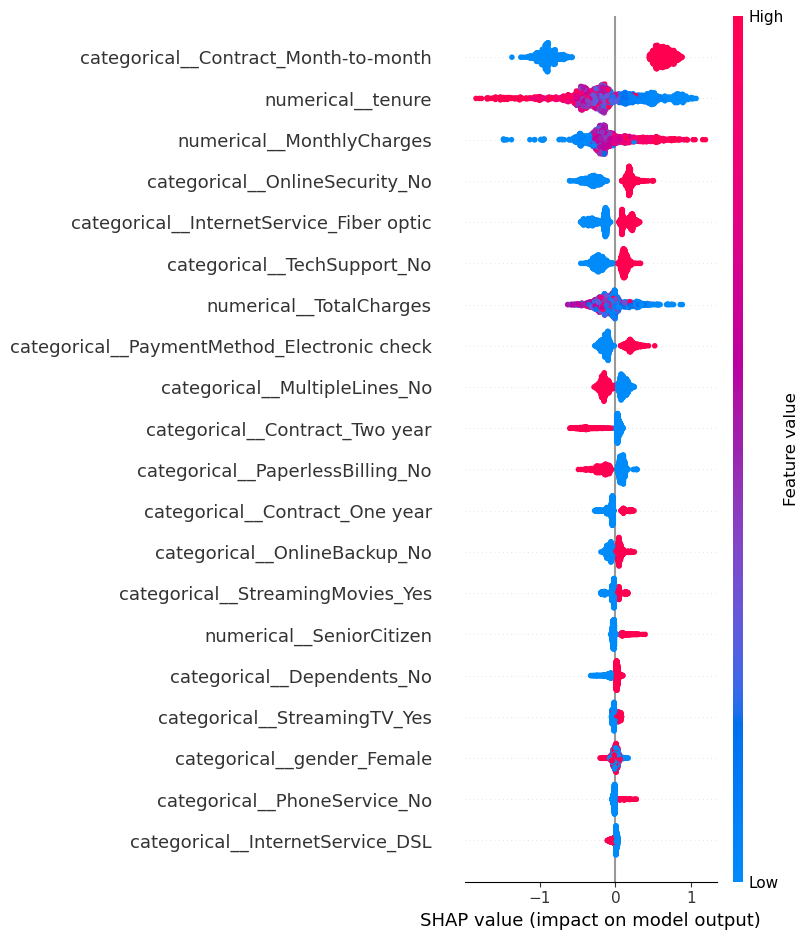

In [39]:
shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names
)

In [41]:
customer_index = 0
customer_shap = shap_values[customer_index]
print(X_test.iloc[customer_index])
print(xgb_pipeline.predict(X_test.iloc[[customer_index]]))
print(xgb_pipeline.predict_proba(X_test.iloc[[customer_index]]))
X_test.iloc[[customer_index]]

gender                                 Male
SeniorCitizen                             0
Partner                                 Yes
Dependents                              Yes
tenure                                   72
PhoneService                            Yes
MultipleLines                           Yes
InternetService                 Fiber optic
OnlineSecurity                          Yes
OnlineBackup                            Yes
DeviceProtection                        Yes
TechSupport                             Yes
StreamingTV                             Yes
StreamingMovies                         Yes
Contract                           Two year
PaperlessBilling                        Yes
PaymentMethod       Credit card (automatic)
MonthlyCharges                       114.05
TotalCharges                         8468.2
Name: 437, dtype: object
[0]
[[0.9898317  0.01016831]]


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
437,Male,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),114.05,8468.2


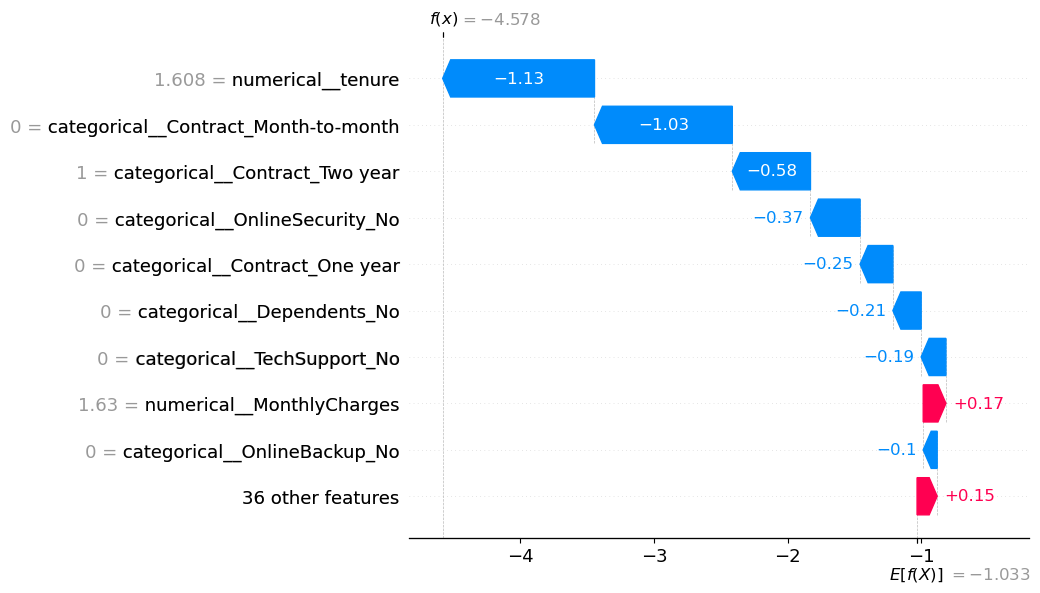

In [45]:
customer_explanation = explainer(
    X_test_processed[customer_index:customer_index + 1]
)

customer_explanation.feature_names = feature_names

shap.waterfall_plot(customer_explanation[0])

In [47]:
import joblib

joblib.dump(xgb_pipeline, "../models/churn_model.pkl")
joblib.dump(0.35, "../models/churn_threshold.pkl")

['../models/churn_threshold.pkl']